<a href="https://colab.research.google.com/github/guttabhavya4465/Student-Career-Recommendation-using-ANN/blob/main/student_prediction_microproject_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

In [ ]:

df = pd.read_excel("Dataset Project 404.xlsx", sheet_name="original")


In [ ]:

df = df[features + [target]].copy()
df[target] = df[target].astype(str).str.strip()
df = df.dropna()


In [ ]:

features = [
    'Linguistic',
    'Musical',
    'Bodily',
    'Logical - Mathematical',
    'Spatial-Visualization',
    'Interpersonal',
    'Intrapersonal',
    'Naturalist'
]
# Target column (career/job recommendation)
target = 'Job profession'

In [ ]:
# 5. Prepare X and y
X = df[features].values
y = df[target].values

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert target into one-hot encoding
y_categorical = to_categorical(y_encoded)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_categorical.shape[1], activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1089 - loss: 3.8299 - val_accuracy: 0.3646 - val_loss: 2.8688
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4518 - loss: 2.1601 - val_accuracy: 0.7535 - val_loss: 1.2134
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6111 - loss: 1.2843 - val_accuracy: 0.8160 - val_loss: 0.7249
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6797 - loss: 0.9839 - val_accuracy: 0.8333 - val_loss: 0.5752
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7144 - loss: 0.8357 - val_accuracy: 0.8750 - val_loss: 0.4660
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7574 - loss: 0.7250 - val_accuracy: 0.8611 - val_loss: 0.4196
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7769 - loss: 0.6399 - val_accuracy: 0.8958 - val_loss: 0.3629
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7678 - loss: 0.6450 - val_accuracy: 0.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.1921454519033432
Test Accuracy: 0.9277777671813965


In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\nClassification Metrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)


Classification Metrics:
Accuracy : 0.9277777777777778
Precision: 0.9251868501868502
Recall   : 0.9277777777777778
F1-Score : 0.9217207235721392


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))



Classification Report:

                                                                                                precision    recall  f1-score   support

                                                                               Actor / Actress       0.83      1.00      0.91        10
                                                                                       Actuary       0.91      1.00      0.95        10
                                                                                Anthropologist       1.00      1.00      1.00        10
                                                                                  Archeologist       1.00      1.00      1.00        10
                                                                                        Artist       1.00      1.00      1.00        10
                                                                                    Astronomer       1.00      1.00      1.00        10
                      

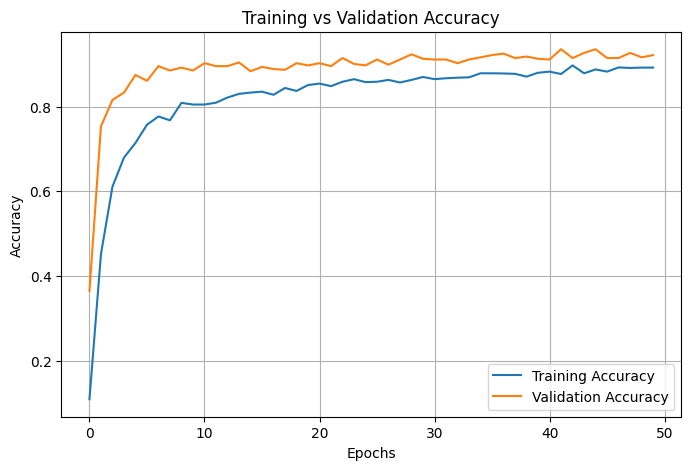

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

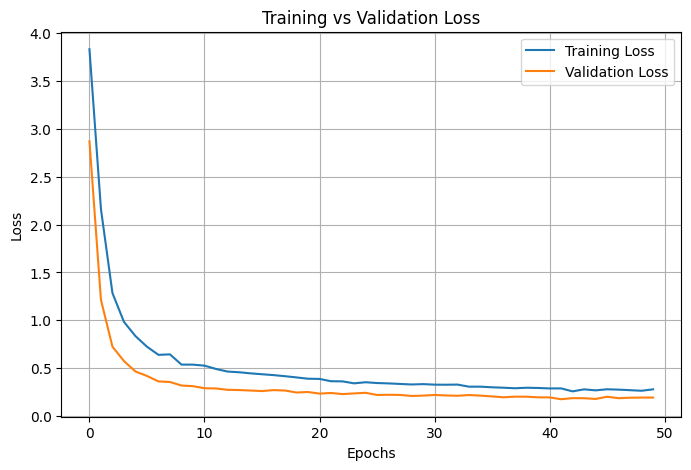

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 18. Predict career for a new student
sample_student = np.array([[15, 8, 12, 18, 16, 14, 17, 10]])
# Example order:
# Linguistic, Musical, Bodily, Logical-Mathematical, Spatial-Visualization,
# Interpersonal, Intrapersonal, Naturalist

sample_student_scaled = scaler.transform(sample_student)
sample_pred = model.predict(sample_student_scaled)
predicted_class = np.argmax(sample_pred, axis=1)[0]
predicted_job = label_encoder.inverse_transform([predicted_class])[0]

print("\nRecommended Career Path for sample student:", predicted_job)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Recommended Career Path for sample student: Engineer
